In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from d2l import torch as d2l

### Exercise 1

Deep learning uses many different number formats, including FP64 double precision (used extremely rarely), FP32 single precision, BFLOAT16 (good for compressed representations), FP16 (very unstable), TF32 (a new format from NVIDIA), and INT8. Compute the smallest and largest argument of the exponential function for which the result does not lead to numerical underflow or overflow.

In [1]:
import numpy as np

def exp_limits(dtype):
    f = np.finfo(dtype)
    
    max_val = f.max                # largest representable number
    min_normal = f.tiny            # smallest positive *normal*
    
    # smallest positive subnormal
    min_subnormal = np.nextafter(dtype(0), dtype(1), dtype=dtype)
    
    xmax = np.log(max_val)
    xmin_sub = np.log(min_subnormal)
    xmin_normal = np.log(min_normal)
    
    return {
        "dtype": dtype,
        "max_val": max_val,
        "min_normal": min_normal,
        "min_subnormal": min_subnormal,
        "log(max)": xmax,
        "log(min_subnormal)": xmin_sub,
        "log(min_normal)": xmin_normal
    }

dtypes = [np.float16, np.float32, np.float64]

for dt in dtypes:
    res = exp_limits(dt)
    print(f"\n===== {dt} =====")
    for k,v in res.items():
        print(f"{k:20}: {v}")


===== <class 'numpy.float16'> =====
dtype               : <class 'numpy.float16'>
max_val             : 65504.0
min_normal          : 6.103515625e-05
min_subnormal       : 5.960464477539063e-08
log(max)            : 11.09375
log(min_subnormal)  : -16.640625
log(min_normal)     : -9.703125

===== <class 'numpy.float32'> =====
dtype               : <class 'numpy.float32'>
max_val             : 3.4028234663852886e+38
min_normal          : 1.1754943508222875e-38
min_subnormal       : 1.401298464324817e-45
log(max)            : 88.72283935546875
log(min_subnormal)  : -103.2789306640625
log(min_normal)     : -87.3365478515625

===== <class 'numpy.float64'> =====
dtype               : <class 'numpy.float64'>
max_val             : 1.7976931348623157e+308
min_normal          : 2.2250738585072014e-308
min_subnormal       : 5e-324
log(max)            : 709.782712893384
log(min_subnormal)  : -744.4400719213812
log(min_normal)     : -708.3964185322641


`np.nextafter(a, b)` returns:
* the next representatable floating-point number after `a` in the direction of `b`.

So mathematically:
$$nextafter(a, b)$$
means move one floating-point step from `a` toward `b`.

Example:
``
np.afternext(1.0, 2.0)
``
-> the next float larger than 1.0

We want the smallest positive number representable.

The floating-point numbers near zero look like:
$$0 < x_1 < x_2 < x_3 < ...$$
The first positive number after zero is the smallest representable value.

So we compute:
```
np.nextafter(0, 1)
```
which means
* move from 0 in the direction of 1
This returns the first positive floating-point number.

`np.finfo(dtype).tiny` returns
* smallest normal number
But floating-point formats also have subnormal numbers, which are even smaller.

Using `tiny` would miss the true undeflow boundary.


### Exercise 3

Increase the number of epochs for training. Why might the validation accuracy decrease after a while? How could we fix this?

In [3]:
class SoftmaxRegression(d2l.Classifier):  #@save
    """The softmax regression model."""
    def __init__(self, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.LazyLinear(num_outputs))

    def forward(self, X):
        return self.net(X)

In [4]:
@d2l.add_to_class(d2l.Classifier)  #@save
def loss(self, Y_hat, Y, averaged=True):
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    Y = Y.reshape((-1,))
    return F.cross_entropy(
        Y_hat, Y, reduction='mean' if averaged else 'none')

In [5]:
# 1) disable D2L plotting
class SoftmaxRegressionNoPlot(SoftmaxRegression):
    def plot(self, key, value, train):
        pass

In [6]:
# 2) do validation once, after training
@torch.no_grad()
def evaluate_val_accuracy(model, data):
    model.eval()
    correct, total = 0, 0
    for X, y in data.val_dataloader():
        y_hat = model(X)
        pred = y_hat.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()
    model.train()
    return correct / total

In [7]:
def run_one_max_epochs(max_epochs, lr=0.1, batch_size=256, repeats=3, seed_base=0):
    vals = []
    for r in range(repeats):
        torch.manual_seed(seed_base + r)

        data = d2l.FashionMNIST(batch_size=batch_size)
        model = SoftmaxRegressionNoPlot(num_outputs=10, lr=lr)

        trainer = d2l.Trainer(max_epochs=max_epochs)
        trainer.fit(model, data)          # trains max_epochs epochs
        vals.append(evaluate_val_accuracy(model, data))  # one validation at the end

    return sum(vals) / len(vals)

/Users/zouminghao/Desktop/d2l-notes-exercises/venv/lib/python3.11/site-packages/torch/nn/modules/lazy.py:180: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


max_epochs= 1  avg_val_acc=0.7799
max_epochs= 2  avg_val_acc=0.8065
max_epochs= 3  avg_val_acc=0.7973
max_epochs= 5  avg_val_acc=0.8236
max_epochs=10  avg_val_acc=0.8293
max_epochs=15  avg_val_acc=0.8364
max_epochs=20  avg_val_acc=0.8357
max_epochs=30  avg_val_acc=0.8325
max_epochs=40  avg_val_acc=0.8390
max_epochs=50  avg_val_acc=0.8439


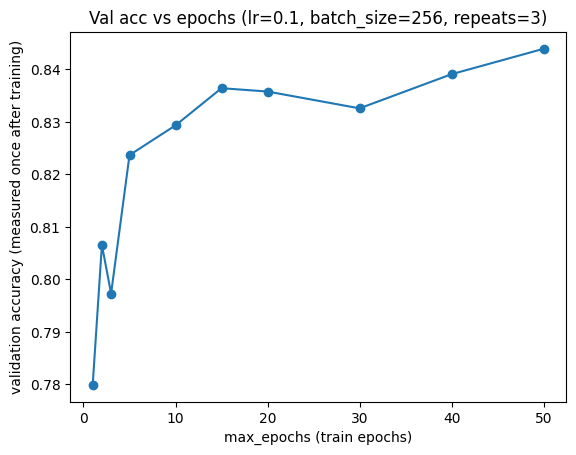

In [8]:
# --- experiment: val accuracy vs number of epochs ---
epochs_list = [1, 2, 3, 5, 10, 15, 20, 30, 40, 50]
lr = 0.1
batch_size = 256
repeats = 3

val_curve = []
for E in epochs_list:
    v = run_one_max_epochs(E, lr=lr, batch_size=batch_size, repeats=repeats)
    val_curve.append(v)
    print(f"max_epochs={E:2d}  avg_val_acc={v:.4f}")

plt.figure()
plt.plot(epochs_list, val_curve, marker='o')
plt.xlabel("max_epochs (train epochs)")
plt.ylabel("validation accuracy (measured once after training)")
plt.title(f"Val acc vs epochs (lr={lr}, batch_size={batch_size}, repeats={repeats})")
plt.show()